### In this example we combine the continuous-wave (cw) `spdc.py` functions to generate second order moments and the `utils.py` update functions to study SU(1,1) interferometric systems. Refer to `example_cw.ipynb` and `example_updates.ipynb` notebooks for documentation on the functions.

Some aspects of the analysis presented here were used in [arXiv:2601.16941](https://arxiv.org/abs/2601.16941) and [arXiv:2601.23263](https://arxiv.org/abs/2601.23263).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.spdc import Scw
from NeedALight.utils import Update_bs, Update_spdc

For the cw SU(1,1) interferometer, we consider two lossless squeezers and allow for idler-only additional dispersion and idler-only loss to incur between both squeezers. We consider the same dispersions and losses as in the `example_cw.ipynb` notebook. Note that we convert the decay rates to transmission rates as $\eta = e^{-\kappa l}$

### No additional dispersion

First we consider the case where there is no additional dispersion in between the squeezers. This is to show that the second squeezer imprints the effects of idler-only loss onto the signal mode. We consider the cases where the second squeezer acts as a perfect squeezer and perfect anti-squeezer

Initializing all relevant parameters.

In [2]:
#Parameters for calculations
N = 301  # Number of frequency values
l = 1.0  # amplification region length

#Dispersions
v = 0.1  #velocity of all modes
b = 3    #group-velocity dispersion
ts =0.09   #signal cubic term
ti =0.07   #idler cubic term 
#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])
#Dispersion relations
ks = w/v+b*w**2 + ts*w**3
ki = w/v-b*w**2 + ti*w**3

#Absorption
w1 = -2.5     # peak position 1
sig1 = 0.25      # spread 1
str1 = 30/100 # level of absorption.

w2 = 1.5     # peak position 2
sig2 = 0.5     # spread 2
str2 = 1/100 # level of absorption.

kappa_1 = -np.log(str1) * np.exp(-((w - w1) ** 2) / (2 * (sig1) ** 2)) / l
kappa_2 = -np.log(str2) * np.exp(-((w - w2) ** 2) / (2 * (sig2) ** 2)) / l
kappa_I = kappa_1 + kappa_2

eta_i = np.exp(-kappa_I*l)

#Interaction strength
Np = 1.72e-4 # Number of pump photons: Vary this to modify gain values
gamma = np.sqrt(Np)/np.sqrt(2 * np.pi * v**3)

Generating the SU(1,1) interferometer. For the figure, "Sq." refers to the case where the second squeezer acts as a perfect squeezer and "Anti-Sq." when it acts as an anti-squeezer.

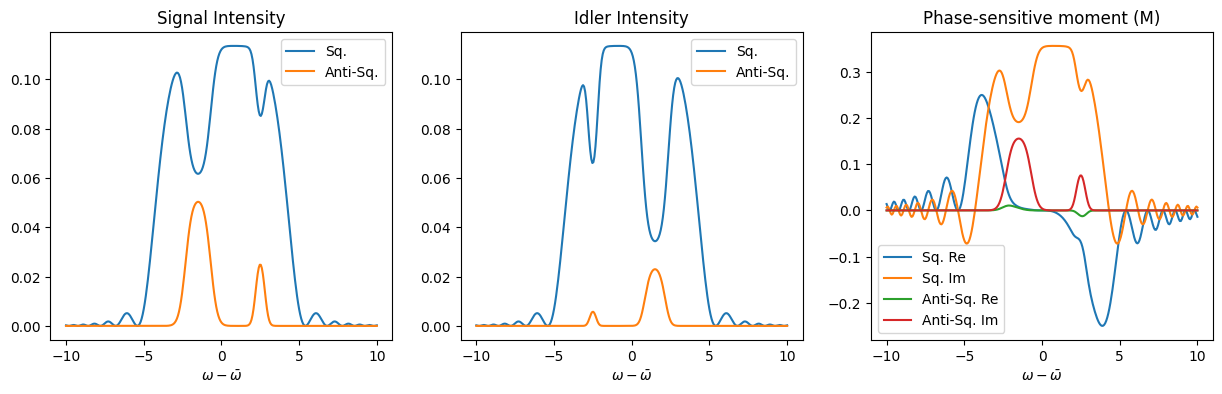

In [3]:
#Vacuum input moments and propagator 
T, _J, M, Nums, Numi = Scw(ks, ki, gamma, l)

#Adding loss via beamsplitter interaction
Ns_bs, Ni_bs, M_bs  = Update_bs(0*eta_i, 0*eta_i, np.ones_like(eta_i), eta_i, Nums, Numi, M)
Ns_bs2, Ni_bs2, M_bs2  = Update_bs(0*eta_i, -np.flip(np.angle(np.diag(np.fliplr(M))**2)), np.ones_like(eta_i), eta_i, Nums, Numi, M)   #for anti-squeezing


#Second nonlinear interaction, 2nd perfect squeezer
Ns_su11_ps, Ni_su11_ps, M_su11_ps = Update_spdc(T, Ns_bs, Ni_bs, M_bs)
#Converting to vectors and Normalizing to unity
Ns_su11_ps = np.real_if_close(np.diag(Ns_su11_ps))
Ni_su11_ps = np.real_if_close(np.diag(Ni_su11_ps))
M_su11_ps = np.diag(np.fliplr(M_su11_ps))

#Second nonlinear interaction, 2nd perfect anti-squeezer
Ns_su11_pas, Ni_su11_pas, M_su11_pas = Update_spdc(T, Ns_bs2, Ni_bs2, M_bs2)
#Converting to vectorsand Normalizing to unity
Ns_su11_pas = np.real_if_close(np.diag(Ns_su11_pas))
Ni_su11_pas = np.real_if_close(np.diag(Ni_su11_pas))
M_su11_pas = np.diag(np.fliplr(M_su11_pas))


#Figure

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(w, Ns_su11_ps, label='Sq.')
axs[0].plot(w, Ns_su11_pas, label='Anti-Sq.')
axs[0].set_xlabel(r"$\omega-\bar{\omega}$")
axs[0].set_title('Signal Intensity')
axs[0].legend()

axs[1].plot(w, Ni_su11_ps, label='Sq.')
axs[1].plot(w, Ni_su11_pas, label='Anti-Sq.')
axs[1].set_xlabel(r"$\omega-\bar{\omega}$")
axs[1].set_title('Idler Intensity')
axs[1].legend()

axs[2].plot(w, M_su11_ps.real, label='Sq. Re')
axs[2].plot(w, M_su11_ps.imag, label='Sq. Im')
axs[2].plot(w, M_su11_pas.real, label='Anti-Sq. Re')
axs[2].plot(w, M_su11_pas.imag, label='Anti-Sq. Im')
axs[2].set_xlabel(r"$\omega-\bar{\omega}$")
axs[2].set_title('Phase-sensitive moment (M)')
axs[2].legend()

plt.show()

Although the signal experiences no absorption, the SU(1,1) interferometer (through the second squeezer) imprints the effects of ilder-only loss onto the signal. The presence of idler-only loss also impedes our ability to perfectly anti-squeeze and we see clear signatures. 

### Additional idler dispersion without absorption

We now consider the case where the idler experiences additional dispersion without absorption in between squeezers. For brevity, and in the optics of undetected photon measurements, we focus only on the signal intensity. We consider linear-dispersion (corresponding to free-space propagation/optical path delays (OPD)) which induce fast and slow oscillations. Experimentally, slow oscillations correspond to shorter OPDs. This is to study how the interference fringes behave.

We consider how different levels of linear dispersion affects the signal intensity for different levels of gain.

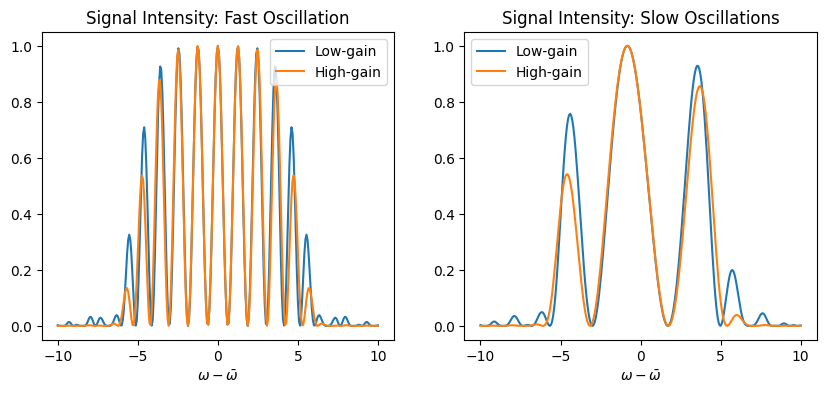

In [4]:
#Propagators and vacuum input moments
Tl, _J, Ml, Numsl, Numil = Scw(ks, ki, gamma, l)  #low-gain
Th, _J, Mh, Numsh, Numih = Scw(ks, ki, 10*gamma, l) #high-gain

#Fast Oscillations
ki_opd = -w*5

Ns_bsT, Ni_bsT, M_bsT  = Update_bs(0*eta_i, ki_opd, np.ones_like(eta_i), np.ones_like(eta_i), Numsl, Numil, Ml) #Additional dispersion 
Ns_low, Ni_low, M_low = Update_spdc(Tl, Ns_bsT, Ni_bsT, M_bsT) #low-gain
Ns_bsT, Ni_bsT, M_bsT  = Update_bs(0*eta_i, ki_opd, np.ones_like(eta_i), np.ones_like(eta_i), Numsh, Numih, Mh) #Additional dispersion 
Ns_high, _Ni_high, _M_high = Update_spdc(Th, Ns_bsT, Ni_bsT, M_bsT) #high-gain

#Slow Oscillations
ki_opd_L = -w*1.2+1 #We shift by 1 to make effects more noticeable

Ns_bsT, Ni_bsT, M_bsT  = Update_bs(0*eta_i, ki_opd_L, np.ones_like(eta_i), np.ones_like(eta_i), Numsl, Numil, Ml) #Additional dispersion 
Ns_low_L, Ni_low_L, M_low_L = Update_spdc(Tl, Ns_bsT, Ni_bsT, M_bsT) #low-gain
Ns_bsT, Ni_bsT, M_bsT  = Update_bs(0*eta_i, ki_opd_L, np.ones_like(eta_i), np.ones_like(eta_i), Numsh, Numih, Mh) #Additional dispersion 
Ns_high_L, _Ni_high_L, _M_high_L = Update_spdc(Th, Ns_bsT, Ni_bsT, M_bsT) #high-gain

#Converting to vectors
Ns_low = np.real_if_close(np.diag(Ns_low))
Ns_high = np.real_if_close(np.diag(Ns_high))

Ns_low_L = np.real_if_close(np.diag(Ns_low_L))
Ns_high_L = np.real_if_close(np.diag(Ns_high_L))



#Figure

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(w, Ns_low/np.amax(Ns_low), label='Low-gain')
axs[0].plot(w, Ns_high/np.amax(Ns_high), label='High-gain')
axs[0].set_xlabel(r"$\omega-\bar{\omega}$")
axs[0].set_title('Signal Intensity: Fast Oscillation')
axs[0].legend()

axs[1].plot(w, Ns_low_L/np.amax(Ns_low_L), label='Low-gain')
axs[1].plot(w, Ns_high_L/np.amax(Ns_high_L), label='High-gain')
axs[1].set_xlabel(r"$\omega-\bar{\omega}$")
axs[1].set_title('Signal Intensity: Slow Oscillations')
axs[1].legend()


plt.show()

In both cases, we see that high-gain effects modify the oscillations closer to the edges of the amplification plateau: the peak positions are shifted.

### Loss and optical path delay

Here we consider the combined effects of idler-only loss and idler-only OPD. We construct a 2D interferogram where we scan the signal intensity over a range of OPDs. We also show the visibility.

In [5]:
# Probe Parameters
Nprobe = 201
Ns_probe = np.zeros([len(w), Nprobe])

Lt_probe = np.linspace(0, -2, Nprobe)

for i in range(Nprobe):
    ki_disp = (w+30)*(Lt_probe[i])   #The shift is to mimic being at non-zero central frequency

    # Update rules
    Ns_bsT, Ni_bsT, M_bsT = Update_bs(ks * 0, ki_disp, np.ones_like(eta_i), eta_i, Nums, Numi, M)
    Ns_total, _Ni_total, _M_total = Update_spdc(T, Ns_bsT, Ni_bsT, M_bsT)

    Ns_probe[:, i] = np.real_if_close(np.diag(Ns_total))

# Normalizing intensity
Ns_probe = Ns_probe / np.amax(Ns_probe)

#Obtaining visibility from interferogram
Vis = np.asarray([(np.amax(Ns_probe[i, :]) - np.amin(Ns_probe[i, :])) / (np.amax(Ns_probe[i, :]) + np.amin(Ns_probe[i, :])) for i in range(len(w))]
)

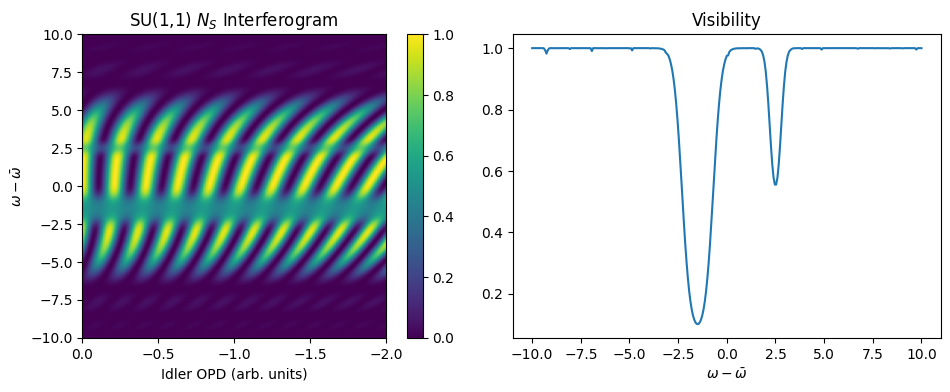

In [6]:
# PLotting the 2D interferogram and visibility
fig, ax = plt.subplots(1,2, figsize=(10, 4))

im = ax[0].imshow(Ns_probe, cmap="viridis", origin='lower', extent=[Lt_probe[0] , Lt_probe[-1] , w[0], w[-1]], aspect=(np.abs(Lt_probe[-1]  - Lt_probe[0] )/ (w[-1] - w[0])))
ax[0].set_xlabel("Idler OPD (arb. units)")
ax[0].set_ylabel(r"$\omega-\bar{\omega}$")
ax[0].set_title(r"SU(1,1) $N_{S}$ Interferogram")
plt.colorbar(im, orientation="vertical")

ax[1].plot(w,Vis)
ax[1].set_xlabel(r"$\omega-\bar{\omega}$")
ax[1].set_title('Visibility')

fig.tight_layout()
plt.show()

We see clear signatures of the idler-only loss on the 2D signal interferogram and visibility.